# Synthetic-100: effect of MiSTIC ensemble size (10 seeds)

This notebook isolates the effect of increasing the MiSTIC forward-knee ensemble
from 5 to 10 to 20 members. All other settings are fixed: `rank_weight=0.90`,
`addition_factor=0.1`, `max_features=20`, separate feature sets and parameters,
`tune_models_each_step=False`, final knee retuning, and no ensemble-validation
holdout. Every model uses the same 375 training rows and the same untouched
125-row blind set. The ten seeds vary only inner model construction.

The previously executed ten-seed sklearn references are merged for context.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svc, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))

X_values, y_values = make_classification(
    n_samples=N_SAMPLES, n_features=N_FEATURES,
    n_informative=N_INFORMATIVE, n_redundant=N_REDUNDANT,
    n_repeated=0, n_classes=2, weights=[0.55, 0.45],
    class_sep=1.0, flip_y=0.03, shuffle=False, random_state=2026,
)
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="class")

BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
NUM_MODELS = 5
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]

X_train, X_blind, y_train, y_blind = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=BLIND_SET_SEED,
)
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")


Training rows: 375; fixed blind rows: 125


In [3]:
def metric_row(y_true, predictions, decision_values):
    return {
        "roc_auc": roc_auc_score(y_true, decision_values),
        "f1": f1_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "accuracy": accuracy_score(y_true, predictions),
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def fit_sklearn_reference(features, seed):
    pipeline = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced")),
    ])
    search = GridSearchCV(
        pipeline,
        {"svc__C": C_VALUES, "svc__gamma": GAMMA_VALUES},
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )
    return search.fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(
        X_scaled, np.asarray(y_train), num_feature_medoids=20,
        ensemble_validation_size=0.0,
        ensemble_validation_random_seed=50_000,
        ensemble_validation_stratify=True,
    )
    splits.classification(
        num_sets=num_models, validation_size=INNER_VALIDATION_SIZE,
        random_seed=seed,
    )
    ensemble = svmSet(
        SVC(kernel="precomputed", class_weight="balanced"), splits,
        score_method=score_svc(weight=1.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [paramSet(model={"C": c}, kernel={"gamma": g})
            for c in C_VALUES for g in GAMMA_VALUES]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn_reference(features, seed)
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "num_features": len(features), "signal_recall": recall,
        "signal_precision": precision, "cv_best_score": model.best_score_,
        "best_C": model.best_params_["svc__C"],
        "best_gamma": model.best_params_["svc__gamma"],
        **metric_row(y_blind, model.predict(X_blind.iloc[:, features]),
                     model.decision_function(X_blind.iloc[:, features])),
    }


## Execute the paired 10-seed comparison

RFE is fitted only on the training data. Since its selector is deterministic,
its selected feature set is constant here; the seed still changes the four-fold
CV partitions used to tune the final RBF-SVM. MiSTIC’s unified reference is
seed-specific and uses no blind-set information.


In [4]:
rows = []
MEMBER_COUNTS = [5, 10, 20]

for num_models in MEMBER_COUNTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, num_models)
        X_blind_scaled = scaler.transform(X_blind)
        top20 = ranked_unified_features(ensemble, 20)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(num_models)
        ])
        disagreement = np.mean([
            np.mean(member_predictions[:, i] != member_predictions[:, j])
            for i in range(num_models) for j in range(i + 1, num_models)
        ]) if num_models > 1 else 0.0
        rows.append({
            "seed": seed,
            "method": f"MiSTIC forward-knee ({num_models} members)",
            "rank_weight": RANK_WEIGHT,
            "num_models": num_models,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "min_member_features": selected_counts.min(),
            "max_member_features": selected_counts.max(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall,
            "top20_signal_precision": precision,
            "member_disagreement": disagreement,
            "elapsed_seconds": time.perf_counter() - started,
            **metric_row(y_blind, ensemble.predict(X_blind_scaled),
                         ensemble.decision_function(X_blind_scaled)),
        })
        print(f"members={num_models}, seed={seed}, knee={knee_count}, "
              f"elapsed={rows[-1]['elapsed_seconds']:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_rank09_member_count_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.698


Number of Features: 10, Score: 0.796


Number of Features: 19, Score: 0.781


Number of Features: 20, Score: 0.782
Number of Features: 100, Score: 0.768


members=5, seed=0, knee=10, elapsed=5.8s


...

Number of Features: 10, Score: 0.778


Number of Features: 19, Score: 0.768


Number of Features: 20, Score: 0.767
Number of Features: 100, Score: 0.748


members=20, seed=9, knee=10, elapsed=32.9s


,seed,method,rank_weight,num_models,knee_feature_count,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds,roc_auc,f1,balanced_accuracy,accuracy
0,0,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,16,0.60,0.750000,0.086400,5.821476,0.971273,0.894737,0.904633,0.904
1,1,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,15,0.60,0.800000,0.070400,5.386385,0.966615,0.886957,0.897386,0.896
2,2,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,16,0.65,0.812500,0.088000,5.546439,0.969979,0.896552,0.906315,0.904
3,3,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,16,0.70,0.875000,0.067200,5.379918,0.969203,0.882883,0.894022,0.896
4,4,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,17,0.60,0.705882,0.083200,5.393969,0.962733,0.877193,0.888458,0.888
5,5,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,16,0.65,0.812500,0.065600,5.616135,0.966097,0.888889,0.899068,0.896
6,6,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,18,0.65,0.722222,0.078400,5.388815,0.970497,0.884956,0.895704,0.896
7,7,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,17,0.70,0.823529,0.084800,5.530305,0.962992,0.890756,0.900751,0.896
8,8,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,14,0.65,0.928571,0.078400,5.545123,0.970497,0.904348,0.913561,0.912
9,9,MiSTIC forward-knee (5 members),0.9,5,10,10.0,10,10,16,0.70,0.875000,0.060800,5.304544,0.975155,0.894737,0.904633,0.904


In [5]:
metrics = [
    "roc_auc", "f1", "balanced_accuracy", "accuracy",
    "knee_feature_count", "mean_member_features", "num_unified_features",
    "top20_signal_recall", "top20_signal_precision", "member_disagreement",
]
summary = results.groupby("num_models")[metrics].agg(["mean", "std"])
summary.round(4)


roc_auc              f1         balanced_accuracy         accuracy  \
              mean     std    mean     std              mean     std     mean   
num_models                                                                      
5           0.9685  0.0039  0.8902  0.0078            0.9005  0.0072   0.8992   
10          0.9708  0.0036  0.8993  0.0099            0.9089  0.0092   0.9072   
20          0.9709  0.0022  0.8899  0.0141            0.9003  0.0129   0.8992   

                   knee_feature_count      mean_member_features       \
               std               mean  std                 mean  std   
num_models                                                             
5           0.0067               10.0  0.0                 10.0  0.0   
10          0.0086               10.0  0.0                 10.0  0.0   
20          0.0120               10.0  0.0                 10.0  0.0   

           num_unified_features         top20_signal_recall          \
                           mean     std                mean     std   
num_models                                                            
5                          16.1  1.1005                0.65  0.0408   
10                         19.7  1.8886                0.69  0.0516   
20                         24.8  2.2509                0.69  0.0211   

           top20_signal_precision         member_disagreement          
                             mean     std                mean     std  
num_models                                                             
5                          0.8105  0.0707              0.0763  0.0097  
10                         0.7236  0.0465              0.0866  0.0121  
20                         0.6900  0.0211              0.0944  0.0099

In [6]:
baseline = results.query("num_models == 5").set_index("seed")
paired_rows = []
for count in [10, 20]:
    candidate = results.query("num_models == @count").set_index("seed")
    for metric in ["roc_auc", "f1", "balanced_accuracy", "accuracy"]:
        delta = candidate[metric] - baseline[metric]
        paired_rows.append({
            "comparison": f"{count} minus 5 members",
            "metric": metric,
            "mean_difference": delta.mean(),
            "std_difference": delta.std(ddof=1),
            "larger_wins": int((delta > 0).sum()),
            "ties": int((delta == 0).sum()),
            "larger_losses": int((delta < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,comparison,metric,mean_difference,std_difference,larger_wins,ties,larger_losses
0,10 minus 5 members,roc_auc,0.0023,0.0035,8,0,2
1,10 minus 5 members,f1,0.0091,0.0124,6,1,3
2,10 minus 5 members,balanced_accuracy,0.0084,0.0115,6,1,3
3,10 minus 5 members,accuracy,0.0080,0.0107,6,2,2
4,20 minus 5 members,roc_auc,0.0024,0.0029,9,0,1
5,20 minus 5 members,f1,-0.0003,0.0181,6,0,4
6,20 minus 5 members,balanced_accuracy,-0.0002,0.0166,6,0,4
7,20 minus 5 members,accuracy,0.0000,0.0146,6,0,4


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_61922/3274497134.py:28: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="roc_auc", order=order,


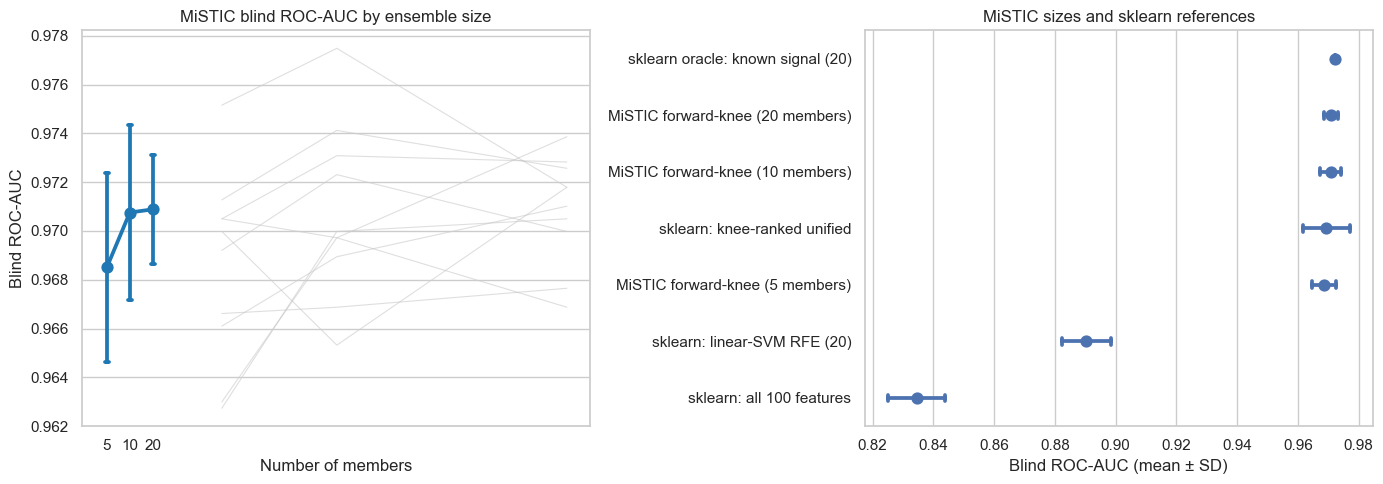

In [7]:
reference_results = pd.read_csv(
    repo_root / "validation/Synthetic100_rank09_vs_sklearn_10seeds_results.csv"
)
references = reference_results[
    reference_results["method"].isin([
        "sklearn: knee-ranked unified",
        "sklearn: linear-SVM RFE (20)",
        "sklearn: all 100 features",
        "sklearn oracle: known signal (20)",
    ])
].copy()
plot_data = pd.concat([
    results[["seed", "method", "roc_auc", "f1", "balanced_accuracy", "accuracy"]],
    references[["seed", "method", "roc_auc", "f1", "balanced_accuracy", "accuracy"]],
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.pointplot(data=results, x="num_models", y="roc_auc", errorbar="sd",
              capsize=0.15, color="tab:blue", ax=axes[0])
for _, seed_data in results.groupby("seed"):
    axes[0].plot(seed_data["num_models"], seed_data["roc_auc"],
                 color="0.75", alpha=0.5, linewidth=0.8, zorder=0)
axes[0].set_title("MiSTIC blind ROC-AUC by ensemble size")
axes[0].set_xlabel("Number of members")
axes[0].set_ylabel("Blind ROC-AUC")

order = plot_data.groupby("method")["roc_auc"].mean().sort_values(ascending=False).index
sns.pointplot(data=plot_data, y="method", x="roc_auc", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=axes[1])
axes[1].set_title("MiSTIC sizes and sklearn references")
axes[1].set_xlabel("Blind ROC-AUC (mean ± SD)")
axes[1].set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_rank09_member_count_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation

All paired differences reuse the same blind observations. They describe
sensitivity to the inner seed and member count rather than uncertainty across
independent test datasets.
